# 03 骑行需求规律分析

本 Notebook 基于 02 构建的清洗后骑行事件表 `trip_base_202407.csv`，分析 2024 年 7 月 Citi Bike 的整体骑行需求规律。

本节重点关注日期趋势、小时分布、星期差异、工作日与周末差异以及不同时段的骑行需求结构，用于判断共享单车需求是否具有明显的通勤高峰和周期性特征。

## 1 导入依赖并设置项目路径

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

DATA_CLEAN_DIR = Path("../data_clean")
OUTPUT_DIR = Path("../outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

file_path = DATA_CLEAN_DIR / "trip_base_202407.csv"

## 2 读取清洗后的骑行事件表

In [4]:
dtype_map = {
    "ride_id": "string",
    "rideable_type": "string",
    "start_station_name": "string",
    "start_station_id": "string",
    "end_station_name": "string",
    "end_station_id": "string",
    "member_casual": "string",
    "start_month": "string",
    "day_of_week": "string",
    "time_period": "string",
    "duration_group": "string",
}

trip_base = pd.read_csv(
    file_path,
    dtype=dtype_map,
    parse_dates=["started_at", "ended_at", "start_date"],
)

print("记录数:", len(trip_base))
display(trip_base.head())
display(trip_base.dtypes)

记录数: 4720941


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,time_period,duration_group,has_start_station,has_end_station,has_station_pair,has_start_location,has_end_location,has_location_pair,is_station_sample,is_map_sample
0,984F632114B98410,electric_bike,2024-07-11 13:32:52.359,2024-07-11 13:41:04.825,9 Ave & W 18 St,6190.08,9 Ave & W 33 St,6492.08,40.743174,-74.003664,...,daytime,5_10min,True,True,True,True,True,True,True,True
1,9B0E546FDB460C0E,electric_bike,2024-07-13 13:18:42.179,2024-07-13 13:22:46.631,W 42 St & 6 Ave,6517.08,W 49 St & 8 Ave,6747.06,40.754920,-73.984550,...,daytime,0_5min,True,True,True,True,True,True,True,True
2,6B939445A283D985,classic_bike,2024-07-08 20:34:27.848,2024-07-08 20:41:46.350,8 Ave & W 52 St,6816.07,9 Ave & W 33 St,6492.08,40.763707,-73.985162,...,night,5_10min,True,True,True,True,True,True,True,True
3,49444E058931E427,electric_bike,2024-07-14 15:42:44.695,2024-07-14 15:55:54.771,W 120 St & Claremont Ave,7745.07,W 78 St & Broadway,7311.07,40.810949,-73.963400,...,daytime,10_20min,True,True,True,True,True,True,True,True
4,74033CB639411DA0,classic_bike,2024-07-09 08:23:38.797,2024-07-09 08:28:48.647,W 42 St & 6 Ave,6517.08,W 49 St & 8 Ave,6747.06,40.754920,-73.984550,...,morning_peak,5_10min,True,True,True,True,True,True,True,True


ride_id                       string
rideable_type                 string
started_at            datetime64[us]
ended_at              datetime64[us]
start_station_name            string
start_station_id              string
end_station_name              string
end_station_id                string
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                 string
ride_duration_min            float64
start_date            datetime64[us]
start_month                   string
start_hour                     int64
day_of_week                   string
day_of_week_num                int64
is_weekend                      bool
time_period                   string
duration_group                string
has_start_station               bool
has_end_station                 bool
has_station_pair                bool
has_start_location              bool
has_end_location                bool
h

**观察与总结**

`trip_base_202407.csv` 已成功读取，共包含 4720941 条清洗后的骑行事件记录。该表已经在 02 中完成 2024 年 7 月自然月过滤和异常骑行时长处理，后续可以直接作为整体需求规律分析的基础表。

从字段结构看，表中已经包含骑行开始时间、结束时间、骑行时长、日期、小时、星期、周末标记、时段和骑行时长分组等字段，可以支持后续从日期、小时、星期和时段维度分析骑行需求变化。

## 3 检查需求分析基础表

本段检查 `trip_base` 的记录数、骑行ID唯一性、时间范围和骑行时长概况。由于 `trip_base` 已经完成自然月过滤和异常时长过滤，因此可直接作为整体骑行需求分析的基础表。

In [5]:
demand_base = trip_base.copy()

summary = pd.Series(
    {
        "records": len(demand_base),
        "unique_rides": demand_base["ride_id"].nunique(),
        "min_started_at": demand_base["started_at"].min(),
        "max_started_at": demand_base["started_at"].max(),
        "avg_duration_min": demand_base["ride_duration_min"].mean(),
        "median_duration_min": demand_base["ride_duration_min"].median(),
    }
).to_frame("value")

display(summary)

,value
records,4720941
unique_rides,4720941
min_started_at,2024-07-01 00:00:00.191000
max_started_at,2024-07-31 23:57:41.895000
avg_duration_min,14.13168
median_duration_min,9.654083


**观察与总结**

需求分析基础表共有 4720941 条记录，`ride_id` 唯一值数量同样为 4720941，说明该表仍保持“一行一次骑行事件”的基础粒度。

时间范围为 2024 年 7 月 1 日 00:00:00 至 2024 年 7 月 31 日 23:57:41，符合 2024 年 7 月自然月分析口径。

骑行时长方面，平均骑行时长约 14.13 分钟，中位数约 9.65 分钟。平均值高于中位数，说明骑行时长仍呈右偏分布，但 02 中已经剔除了超过 24 小时的极端记录，因此该样本可以用于后续需求规律和骑行行为分析。

## 4 分析每日骑行趋势

本段按日期统计每日骑行次数，用于观察 2024 年 7 月 Citi Bike 的日度需求波动。每日趋势可以帮助判断需求是否存在明显高低峰、异常日期或周期性变化。

In [6]:
daily_demand = (
    demand_base
    .groupby("start_date", as_index=False)
    .agg(
        rides=("ride_id", "count"),
        avg_duration_min=("ride_duration_min", "mean"),
    )
)

daily_demand["ride_share"] = (
    daily_demand["rides"] / daily_demand["rides"].sum()
)

display(daily_demand.head())
display(daily_demand["rides"].describe().to_frame("daily_rides"))

,start_date,rides,avg_duration_min,ride_share
0,2024-07-01,151980,14.036613,0.032193
1,2024-07-02,162119,13.717126,0.034340
2,2024-07-03,155842,13.906019,0.033011
3,2024-07-04,117922,17.934757,0.024978
4,2024-07-05,111116,14.773023,0.023537


,daily_rides
count,31.000000
mean,152288.419355
std,16313.081029
min,111116.000000
25%,146772.000000
50%,151980.000000
75%,166316.000000
max,170957.000000


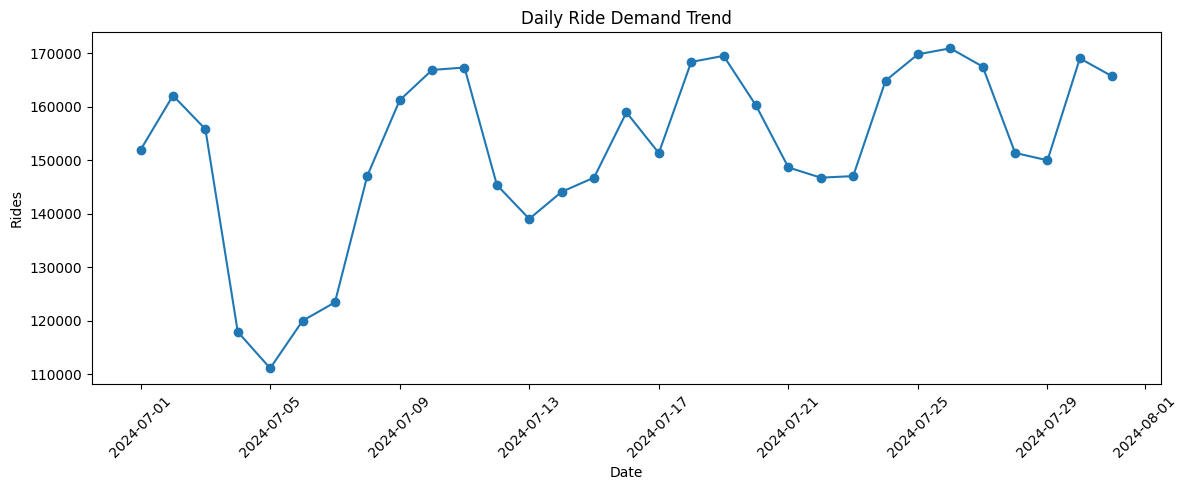

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_demand["start_date"],
    daily_demand["rides"],
    marker="o",
)

plt.title("Daily Ride Demand Trend")
plt.xlabel("Date")
plt.ylabel("Rides")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "01_daily_ride_demand_trend.png", dpi=150, bbox_inches="tight")
plt.show()

**观察与总结**

从日度统计看，2024 年 7 月日均骑行次数约 152288 次，中位数约 151980 次，说明大多数日期的骑行需求处于较稳定的高位水平。

单日骑行次数最低为 111116 次，最高为 170957 次，标准差约 16313 次，说明不同日期之间存在一定波动，但整体没有出现大面积断崖式下降。

从样例数据看，7 月 4 日和 7 月 5 日骑行次数相对较低，分别为 117922 次和 111116 次。后续如果需要解释具体异常日期，可以结合节假日、天气或特殊事件进一步分析；本项目第一版主要关注数据内部呈现出的周期性需求规律。

## 5 分析小时骑行分布

本段按骑行开始小时统计骑行次数，用于识别一天中的骑行需求高峰。共享单车如果具有明显通勤属性，通常会在早高峰或晚高峰出现更高需求。

In [8]:
hourly_demand = (
    demand_base
    .groupby("start_hour", as_index=False)
    .agg(
        rides=("ride_id", "count"),
        avg_duration_min=("ride_duration_min", "mean"),
    )
)

hourly_demand["ride_share"] = (
    hourly_demand["rides"] / hourly_demand["rides"].sum()
)

display(hourly_demand)

,start_hour,rides,avg_duration_min,ride_share
0,0,74869,15.409961,0.015859
1,1,45340,15.477923,0.009604
2,2,29316,15.496688,0.006210
3,3,18672,15.604639,0.003955
4,4,16384,14.078124,0.003470
5,5,33228,11.281465,0.007038
6,6,89327,10.693408,0.018921
7,7,164750,11.093281,0.034898
8,8,257039,11.708865,0.054447
9,9,229602,11.916542,0.048635


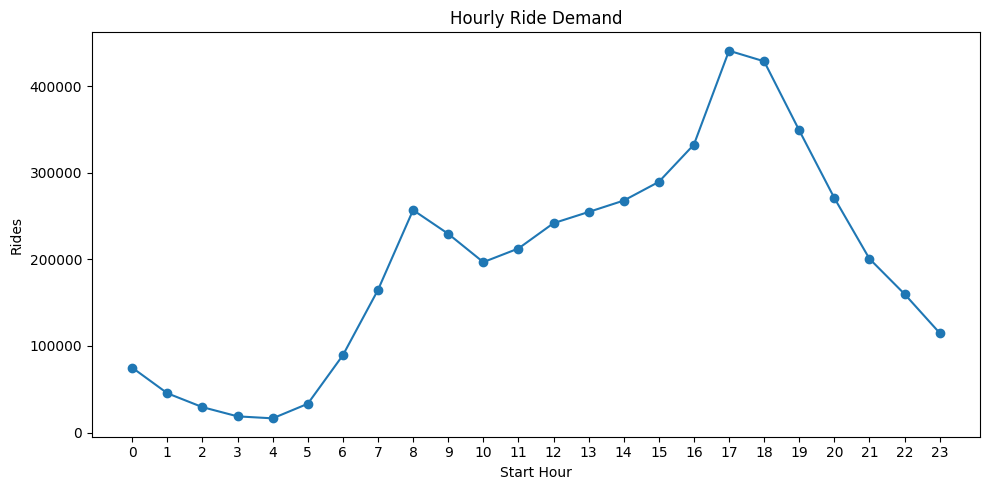

In [9]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_demand["start_hour"],
    hourly_demand["rides"],
    marker="o",
)

plt.title("Hourly Ride Demand")
plt.xlabel("Start Hour")
plt.ylabel("Rides")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

**观察与总结**

从小时分布看，骑行需求在一天内呈现明显的时间集中性，并不是均匀分布。

凌晨 3 点到 5 点骑行需求最低，其中 4 点仅有 16384 次，是全天低谷。6 点以后需求开始上升，8 点达到早高峰局部峰值，骑行次数为 257039 次。

下午和傍晚需求进一步走高，17 点达到全天最高峰，骑行次数为 441147 次；18 点也保持在较高水平，达到 428892 次。说明晚高峰是 2024 年 7 月 Citi Bike 单小时需求压力最大的时段。

整体来看，小时曲线呈现“早高峰 + 晚高峰”的双峰特征，但晚高峰明显强于早高峰。这说明 Citi Bike 不仅服务早间通勤，也在下班、晚间出行和城市短途活动中承担较高需求。

## 6 分析星期日均骑行需求

本段按星期统计骑行需求。由于不同星期在单月中出现的天数可能不同，直接比较总骑行次数可能产生偏差，因此本段同时计算每个星期的出现天数和日均骑行次数，用于更公平地比较星期需求差异。

In [10]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

demand_base["day_of_week"] = pd.Categorical(
    demand_base["day_of_week"],
    categories=weekday_order,
    ordered=True,
)

weekday_demand = (
    demand_base
    .groupby("day_of_week", observed=False, as_index=False)
    .agg(
        total_rides=("ride_id", "count"),
        active_days=("start_date", "nunique"),
        avg_duration_min=("ride_duration_min", "mean"),
    )
)

weekday_demand["avg_daily_rides"] = (
    weekday_demand["total_rides"] / weekday_demand["active_days"]
)

weekday_demand["ride_share"] = (
    weekday_demand["total_rides"] / weekday_demand["total_rides"].sum()
)

display(weekday_demand)

,day_of_week,total_rides,active_days,avg_duration_min,avg_daily_rides,ride_share
0,Monday,742663,5,13.262070,148532.60,0.157312
1,Tuesday,798482,5,13.209856,159696.40,0.169136
2,Wednesday,804748,5,13.072566,160949.60,0.170463
3,Thursday,623548,4,14.354119,155887.00,0.132081
4,Friday,597019,4,14.158041,149254.75,0.126462
5,Saturday,586847,4,16.123155,146711.75,0.124307
6,Sunday,567634,4,15.736723,141908.50,0.120237


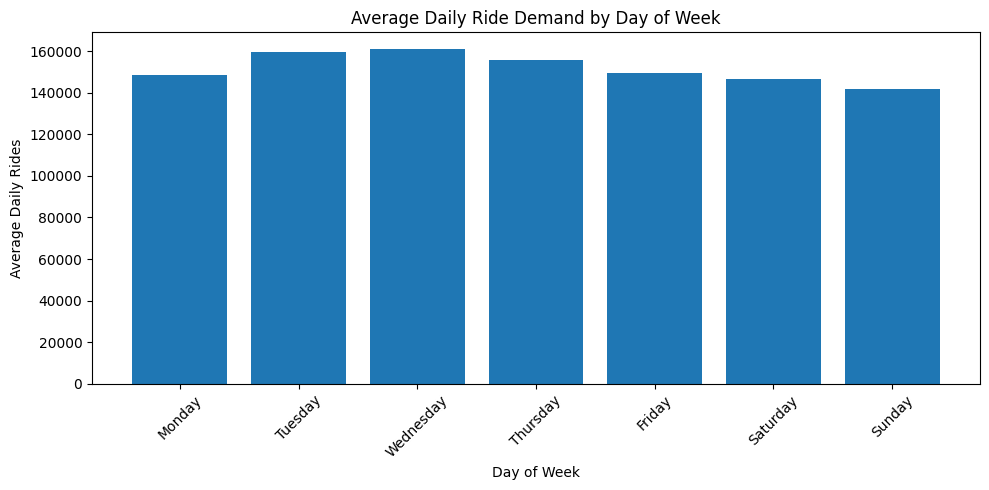

In [11]:
plt.figure(figsize=(10, 5))

plt.bar(
    weekday_demand["day_of_week"].astype(str),
    weekday_demand["avg_daily_rides"],
)

plt.title("Average Daily Ride Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Daily Rides")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**观察与总结**

由于 2024 年 7 月中不同星期出现的天数不同，本节使用日均骑行次数进行比较，比直接比较总骑行次数更合理。

从日均骑行次数看，Wednesday 最高，约 160950 次；Tuesday 次之，约 159696 次；Thursday 约 155887 次。Sunday 最低，约 141909 次。

整体来看，工作日的日均骑行需求普遍高于周末，说明 Citi Bike 在本月具有较明显的工作日使用特征，可能与通勤和日常城市出行需求有关。

同时，周末平均骑行时长更高。Saturday 和 Sunday 的平均骑行时长分别约 16.12 分钟和 15.74 分钟，高于多数工作日。这说明周末虽然日均骑行次数略低，但单次骑行可能更偏向休闲、游览或非通勤出行。

## 7 对比工作日与周末需求

本段基于 `is_weekend` 对比工作日和周末的骑行需求。由于 7 月中工作日数量多于周末数量，不能只看总骑行次数，还需要计算日均骑行次数。

In [12]:
weekday_weekend_demand = (
    demand_base
    .groupby("is_weekend", as_index=False)
    .agg(
        total_rides=("ride_id", "count"),
        active_days=("start_date", "nunique"),
        avg_duration_min=("ride_duration_min", "mean"),
    )
)

weekday_weekend_demand["avg_daily_rides"] = (
    weekday_weekend_demand["total_rides"]
    / weekday_weekend_demand["active_days"]
)

weekday_weekend_demand["day_type"] = np.where(
    weekday_weekend_demand["is_weekend"],
    "weekend",
    "weekday",
)

weekday_weekend_demand = weekday_weekend_demand[
    [
        "day_type",
        "active_days",
        "total_rides",
        "avg_daily_rides",
        "avg_duration_min",
    ]
]

display(weekday_weekend_demand)

,day_type,active_days,total_rides,avg_daily_rides,avg_duration_min
0,weekday,23,3566460,155063.478261,13.548534
1,weekend,8,1154481,144310.125000,15.933154


**观察与总结**

2024 年 7 月共有 23 个工作日和 8 个周末日。工作日总骑行次数为 3566460 次，周末总骑行次数为 1154481 次。

为了避免工作日天数更多导致总量对比失真，本节进一步比较日均骑行次数。工作日日均骑行约 155063 次，周末日均骑行约 144310 次，工作日日均需求约高出 7.45%。

骑行时长方面，工作日平均骑行时长约 13.55 分钟，周末约 15.93 分钟。周末单次骑行时长更长，说明周末使用场景可能更偏向休闲或非固定通勤，而工作日更偏向高频、短时长的日常出行。

## 8 分析不同时段骑行需求强度

本段基于 `time_period` 字段分析不同时段的骑行需求。由于不同时段覆盖的小时数不同，直接比较总骑行次数可能受到时段长度影响。因此，本段同时计算总骑行次数和每小时平均骑行次数，并使用每小时平均骑行次数衡量不同时段的需求强度。

In [13]:
time_period_order = [
    "late_night",
    "morning_peak",
    "daytime",
    "evening_peak",
    "night",
]

time_period_hours = {
    "late_night": 6,
    "morning_peak": 4,
    "daytime": 6,
    "evening_peak": 4,
    "night": 4,
}

demand_base["time_period"] = pd.Categorical(
    demand_base["time_period"],
    categories=time_period_order,
    ordered=True,
)

time_period_demand = (
    demand_base
    .groupby("time_period", observed=False, as_index=False)
    .agg(
        rides=("ride_id", "count"),
        avg_duration_min=("ride_duration_min", "mean"),
    )
)

time_period_demand["ride_share"] = (
    time_period_demand["rides"] / time_period_demand["rides"].sum()
)

time_period_demand["period_hours"] = (
    time_period_demand["time_period"]
    .astype(str)
    .map(time_period_hours)
)

time_period_demand["rides_per_hour"] = (
    time_period_demand["rides"] / time_period_demand["period_hours"]
)

display(time_period_demand)

,time_period,rides,avg_duration_min,ride_share,period_hours,rides_per_hour
0,late_night,217809,14.722462,0.046137,6,36301.500000
1,morning_peak,740718,11.513862,0.156900,4,185179.500000
2,daytime,1463731,14.404965,0.310051,6,243955.166667
3,evening_peak,1551834,14.676833,0.328713,4,387958.500000
4,night,746849,14.887366,0.158199,4,186712.250000


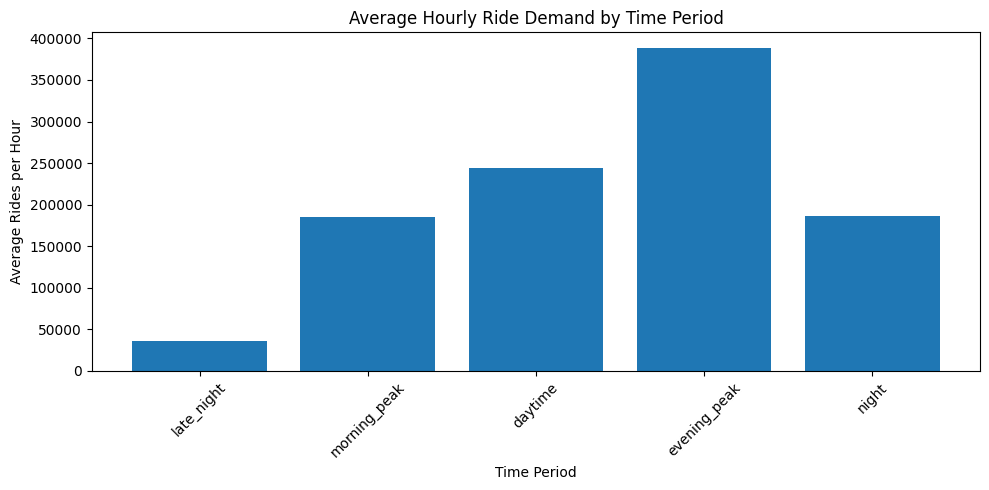

In [14]:
plt.figure(figsize=(10, 5))

plt.bar(
    time_period_demand["time_period"].astype(str),
    time_period_demand["rides_per_hour"],
)

plt.title("Average Hourly Ride Demand by Time Period")
plt.xlabel("Time Period")
plt.ylabel("Average Rides per Hour")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**观察与总结**

从总骑行次数看，晚高峰骑行次数最多，达到 1551834 次，占比约 32.87%；日间骑行次数为 1463731 次，占比约 31.01%。这两个时段合计贡献超过 60% 的骑行需求。

但由于不同时段覆盖的小时数不同，仅比较总骑行次数并不完全公平。因此，本节进一步计算每小时平均骑行次数，用于衡量单位时间内的需求强度。

从需求强度看，晚高峰每小时平均骑行约 387959 次，明显高于其他时段，是本月单位时间需求压力最大的时段。日间每小时平均骑行约 243955 次，位居第二。早高峰和夜间的每小时平均骑行次数接近，分别约 185180 次和 186712 次。

这说明 Citi Bike 的运营调度压力主要集中在晚高峰，其次是日间。后续站点失衡分析可以优先关注晚高峰和日间的站点流入流出变化。

## 9 对比工作日与周末的小时需求曲线

本段进一步将小时维度与工作日/周末维度结合，观察不同日期类型下的小时需求曲线。如果工作日存在明显早晚双峰，而周末更偏向日间出行，则说明两类日期对应的使用场景不同，由于一个月的工作日数量高于周末数量，这里也取日均作为对比参数

In [15]:
hourly_by_day_type = (
    demand_base
    .groupby(["is_weekend", "start_hour"], as_index=False)
    .agg(
        rides=("ride_id", "count"),
        active_days=("start_date", "nunique"),
    )
)

hourly_by_day_type["avg_rides_per_day"] = (
    hourly_by_day_type["rides"] / hourly_by_day_type["active_days"]
)

hourly_by_day_type["day_type"] = np.where(
    hourly_by_day_type["is_weekend"],
    "weekend",
    "weekday",
)

display(hourly_by_day_type.head())

,is_weekend,start_hour,rides,active_days,avg_rides_per_day,day_type
0,False,0,45955,23,1998.043478,weekday
1,False,1,24438,23,1062.521739,weekday
2,False,2,14403,23,626.217391,weekday
3,False,3,8903,23,387.086957,weekday
4,False,4,9932,23,431.826087,weekday


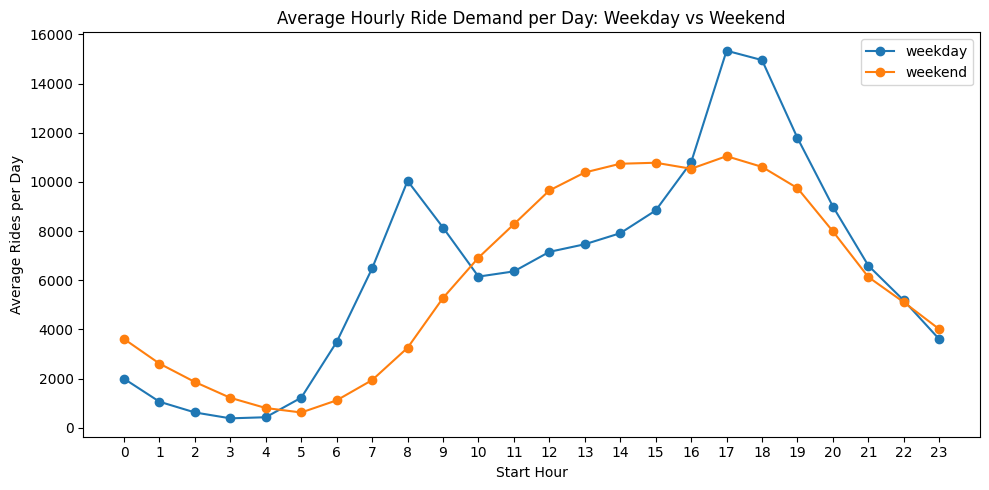

In [18]:
plt.figure(figsize=(10, 5))

for day_type, group_data in hourly_by_day_type.groupby("day_type"):
    plt.plot(
        group_data["start_hour"],
        group_data["avg_rides_per_day"],
        marker="o",
        label=day_type,
    )

plt.title("Average Hourly Ride Demand per Day: Weekday vs Weekend")
plt.xlabel("Start Hour")
plt.ylabel("Average Rides per Day")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "02_hourly_pattern_by_day_type.png", dpi=150, bbox_inches="tight")
plt.show()

**观察与总结**

工作日和周末的小时需求曲线存在明显差异。

工作日曲线呈现更典型的通勤特征：早上 7 点到 9 点出现一轮明显上升，8 点附近形成早高峰；下午 16 点后需求快速上升，并在 17 点到 18 点达到全天最高水平。这说明工作日骑行需求与上下班通勤节奏关系较强。

周末曲线则更平缓，凌晨和上午早段需求相对低，10 点后逐步上升，下午到傍晚保持较高水平。相比工作日，周末没有特别突出的早高峰，更像是日间休闲、游览或非固定时间出行。

因此，运营调度策略不应只使用统一的小时规则。工作日应重点关注早晚高峰的车辆补给和清运，周末则更应关注日间到傍晚的持续性需求。

## 10 汇总本 Notebook 的核心指标

本段汇总 03 中的关键需求指标，便于后续 README 和 Power BI 看板引用。

In [17]:
key_metrics = pd.Series(
    {
        "total_rides": len(demand_base),
        "avg_daily_rides": daily_demand["rides"].mean(),
        "max_daily_rides": daily_demand["rides"].max(),
        "peak_hour": hourly_demand.loc[
            hourly_demand["rides"].idxmax(),
            "start_hour",
        ],
        "peak_hour_rides": hourly_demand["rides"].max(),
        "top_time_period_by_total": time_period_demand.loc[
            time_period_demand["rides"].idxmax(),
            "time_period",
        ],
        "top_time_period_rides": time_period_demand["rides"].max(),
        "top_time_period_by_intensity": time_period_demand.loc[
            time_period_demand["rides_per_hour"].idxmax(),
            "time_period",
        ],
        "top_time_period_rides_per_hour": time_period_demand["rides_per_hour"].max(),
    }
).to_frame("value")

display(key_metrics)

,value
total_rides,4720941
avg_daily_rides,152288.419355
max_daily_rides,170957
peak_hour,17
peak_hour_rides,441147
top_time_period_by_total,evening_peak
top_time_period_rides,1551834
top_time_period_by_intensity,evening_peak
top_time_period_rides_per_hour,387958.5


**观察与总结**

本月清洗后共有 4720941 次有效骑行，日均骑行约 152288 次，最高单日骑行次数为 170957 次。

从小时维度看，17 点是本月骑行需求最高的小时，累计骑行次数为 441147 次，说明晚高峰是最关键的单小时需求窗口。

从时段维度看，晚高峰同时是总骑行次数最高和单位小时需求强度最高的时段。晚高峰总骑行次数为 1551834 次，每小时平均骑行约 387959 次，说明该时段是后续运营调度和站点失衡分析中最值得关注的时间窗口。

## 总结

本 Notebook 基于 `trip_base_202407.csv` 对 2024 年 7 月 Citi Bike 骑行需求规律进行了分析。该表已经在 02 中完成自然月过滤和异常骑行时长处理，共包含 4720941 条有效骑行事件，基础粒度为“一行一次骑行”。

从日度趋势看，7 月日均骑行约 152288 次，单日骑行次数在 111116 次到 170957 次之间波动。整体来看，本月骑行需求保持在较高水平，但不同日期之间仍存在一定波动。7 月 4 日和 7 月 5 日骑行次数相对较低，后续如需解释具体异常日期，可以结合节假日、天气或特殊事件进一步分析。

从小时分布看，骑行需求呈现明显的双峰特征。早上 8 点形成早高峰局部峰值，骑行次数为 257039 次；17 点达到全天最高峰，骑行次数为 441147 次，18 点也保持在 428892 次的高位。晚高峰明显强于早高峰，是本月最核心的单小时需求窗口。

从星期维度看，使用日均骑行次数可以避免不同星期出现天数不同带来的偏差。Wednesday 日均骑行最高，约 160950 次；Sunday 最低，约 141909 次。整体上，工作日日均骑行约 155063 次，高于周末的约 144310 次，说明 Citi Bike 在本月具有较明显的工作日使用特征。

从骑行时长看，周末平均骑行时长约 15.93 分钟，高于工作日的约 13.55 分钟。这说明工作日更偏向高频、短时长的日常出行或通勤场景，而周末虽然日均骑行次数略低，但单次骑行时间更长，可能更偏向休闲、游览或非固定通勤出行。

从时段需求强度看，晚高峰是总量最高、单位小时需求强度也最高的时段。晚高峰总骑行次数为 1551834 次，每小时平均骑行约 387959 次；日间总骑行次数为 1463731 次，每小时平均骑行约 243955 次。相比之下，深夜需求最低，每小时平均骑行约 36302 次。

综合来看，Citi Bike 的骑行需求同时具有通勤属性和日间城市短途出行属性。工作日呈现明显早晚高峰，尤其是晚高峰需求最强；周末需求更集中在日间到傍晚，曲线更加平缓。后续运营策略不应只按统一时间规则调度车辆，而应区分工作日、周末和高峰时段制定不同补车与清运策略。

下一步将在 `04_station_imbalance_analysis.ipynb` 中，进一步分析不同站点的起点需求、终点流入和净流入差异，识别哪些站点可能存在缺车或积车风险，并为车辆调度和站点运营优化提供依据。